# Exploratory Data Analysis Starter

## Import packages

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show plots inline
%matplotlib inline

# Set a clean visual style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [2]:
client_df = pd.read_csv('./client_data.csv')
price_df = pd.read_csv('./price_data.csv')

print('client_df shape:', client_df.shape)
print('price_df shape: ', price_df.shape)

client_df shape: (14606, 26)
price_df shape:  (193002, 8)


You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [5]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [6]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [7]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [8]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


In [9]:
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [10]:
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [11]:
client_df.duplicated().sum()

np.int64(0)

In [12]:
price_df.duplicated().sum()

np.int64(0)

In [13]:
# Fix date columns: object → datetime 
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

# Fix price_date too
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

print('Date columns after conversion:')
print(client_df[date_cols].dtypes)
print(f'\nprice_date dtype: {price_df["price_date"].dtype}')

Date columns after conversion:
date_activ         datetime64[us]
date_end           datetime64[us]
date_modif_prod    datetime64[us]
date_renewal       datetime64[us]
dtype: object

price_date dtype: datetime64[us]


In [14]:
# --- Fix has_gas: 't'/'f' text → proper boolean True/False ---
client_df['has_gas'] = client_df['has_gas'].map({'t': True, 'f': False})

print('has_gas dtype:', client_df['has_gas'].dtype)
print(client_df['has_gas'].value_counts())

has_gas dtype: bool
has_gas
False    11955
True      2651
Name: count, dtype: int64


In [15]:
# Check for hidden 'MISSING' text values
print('=== Text MISSING values in client_df ===')
missing_text = client_df.isin(['MISSING']).sum()
print(missing_text[missing_text > 0])

# Check for true NaN values
print('\n=== True NaN values in client_df ===')
nulls = client_df.isnull().sum()
if nulls.sum() > 0:
    print(nulls[nulls > 0])
else:
    print('No true null values found.')

=== Text MISSING values in client_df ===
channel_sales    3725
origin_up          64
dtype: int64

=== True NaN values in client_df ===
No true null values found.


churn
0    13187
1     1419
Name: count, dtype: int64

Churn rate: 9.7%


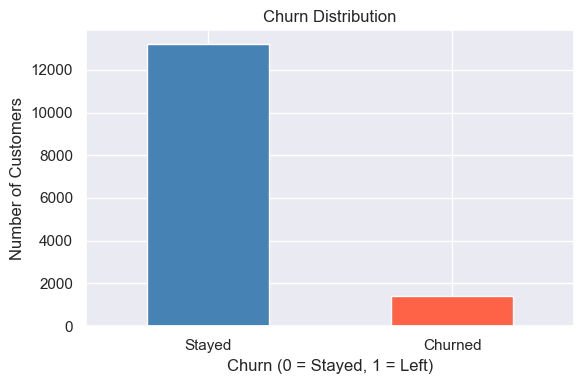

In [16]:
# Count of churned vs stayed
churn_counts = client_df['churn'].value_counts()
print(churn_counts)
print('\nChurn rate: {:.1f}%'.format(client_df['churn'].mean() * 100))

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn (0 = Stayed, 1 = Left)')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['Stayed', 'Churned'], rotation=0)
plt.tight_layout()
plt.show()

---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations. 

In [17]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

print('Price data date range:')
print('From:', price_df['price_date'].min())
print('To:  ', price_df['price_date'].max())

Price data date range:
From: 2015-01-01 00:00:00
To:   2015-12-01 00:00:00


In [18]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

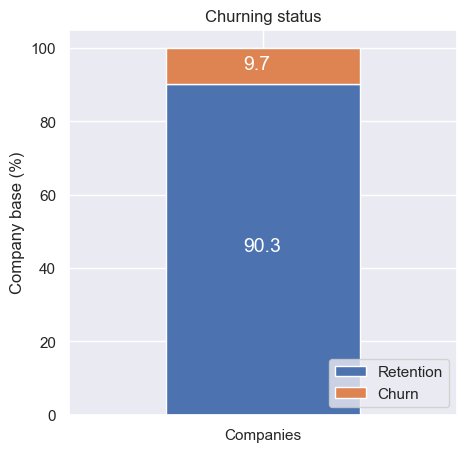

In [19]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

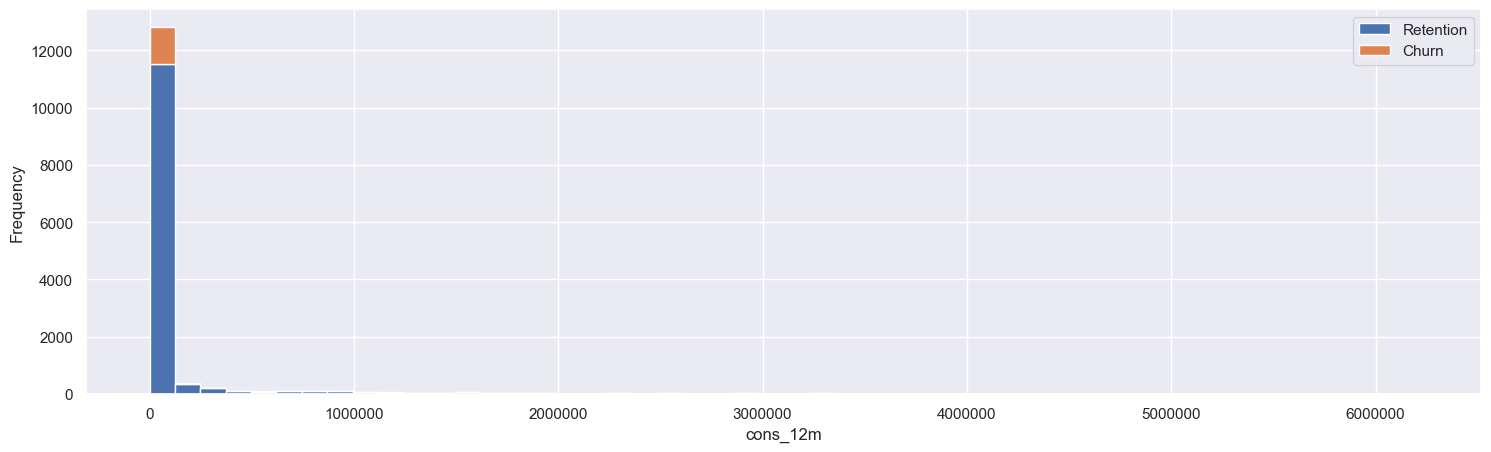

In [20]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

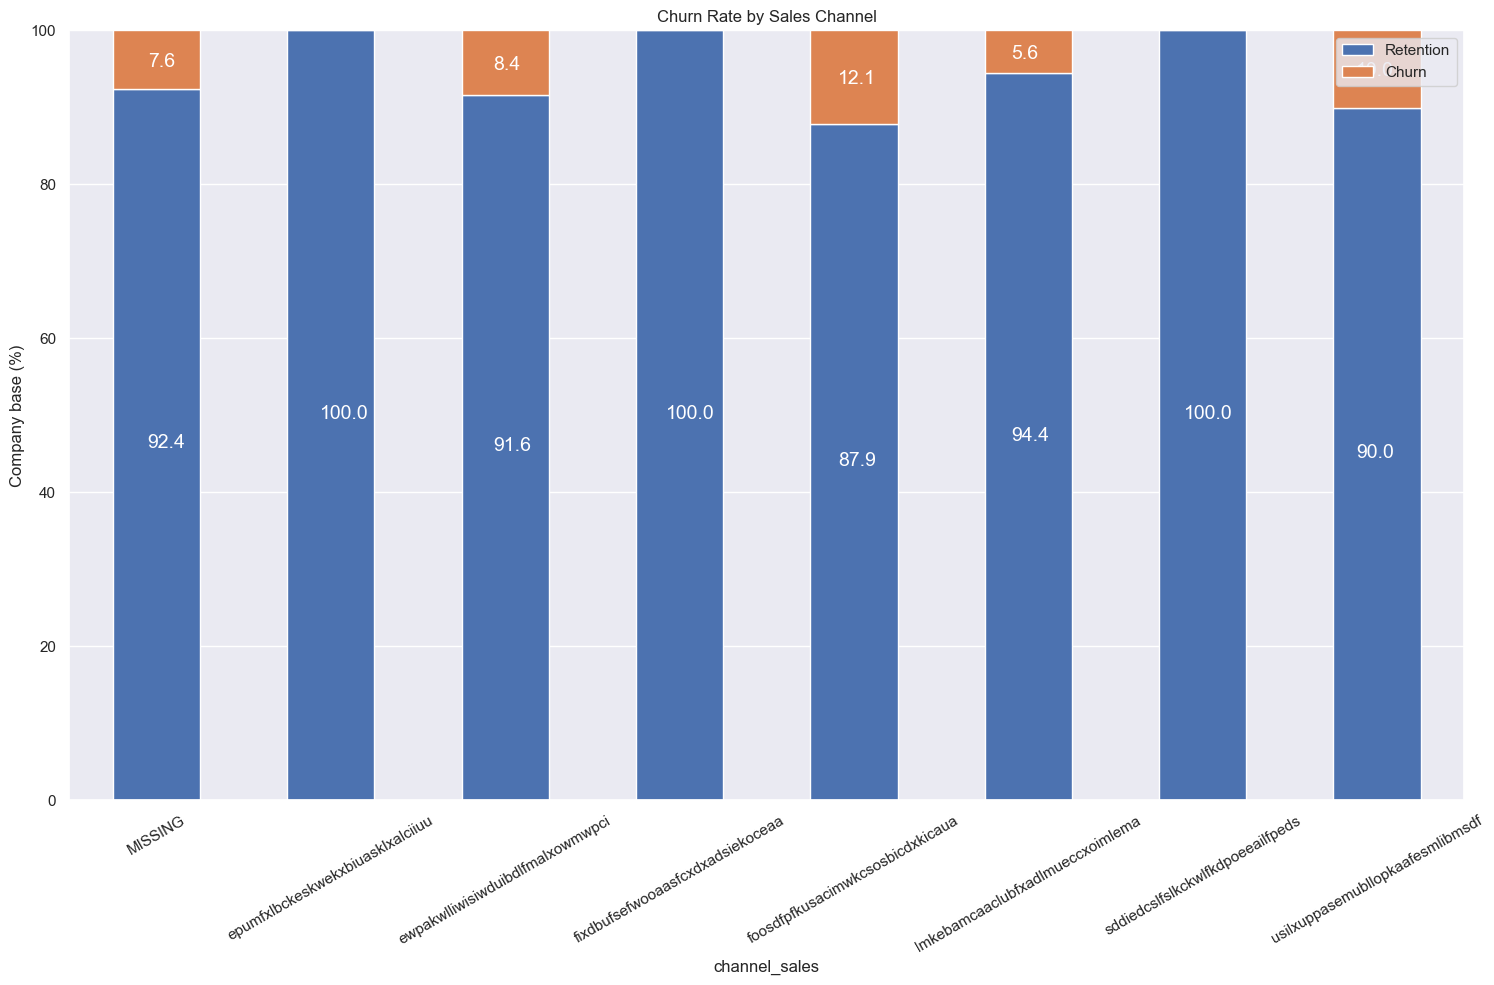

In [21]:
# --- Churn rate by Sales Channel ---
# Each bar shows what % of customers in that channel stayed vs churned
channel_churn = client_df.groupby(
    [client_df['channel_sales'], client_df['churn']]
)['id'].count().unstack(level=1)

channel_percentage = (channel_churn.div(channel_churn.sum(axis=1), axis=0) * 100)
plot_stacked_bars(channel_percentage, 'Churn Rate by Sales Channel', rot_=30)

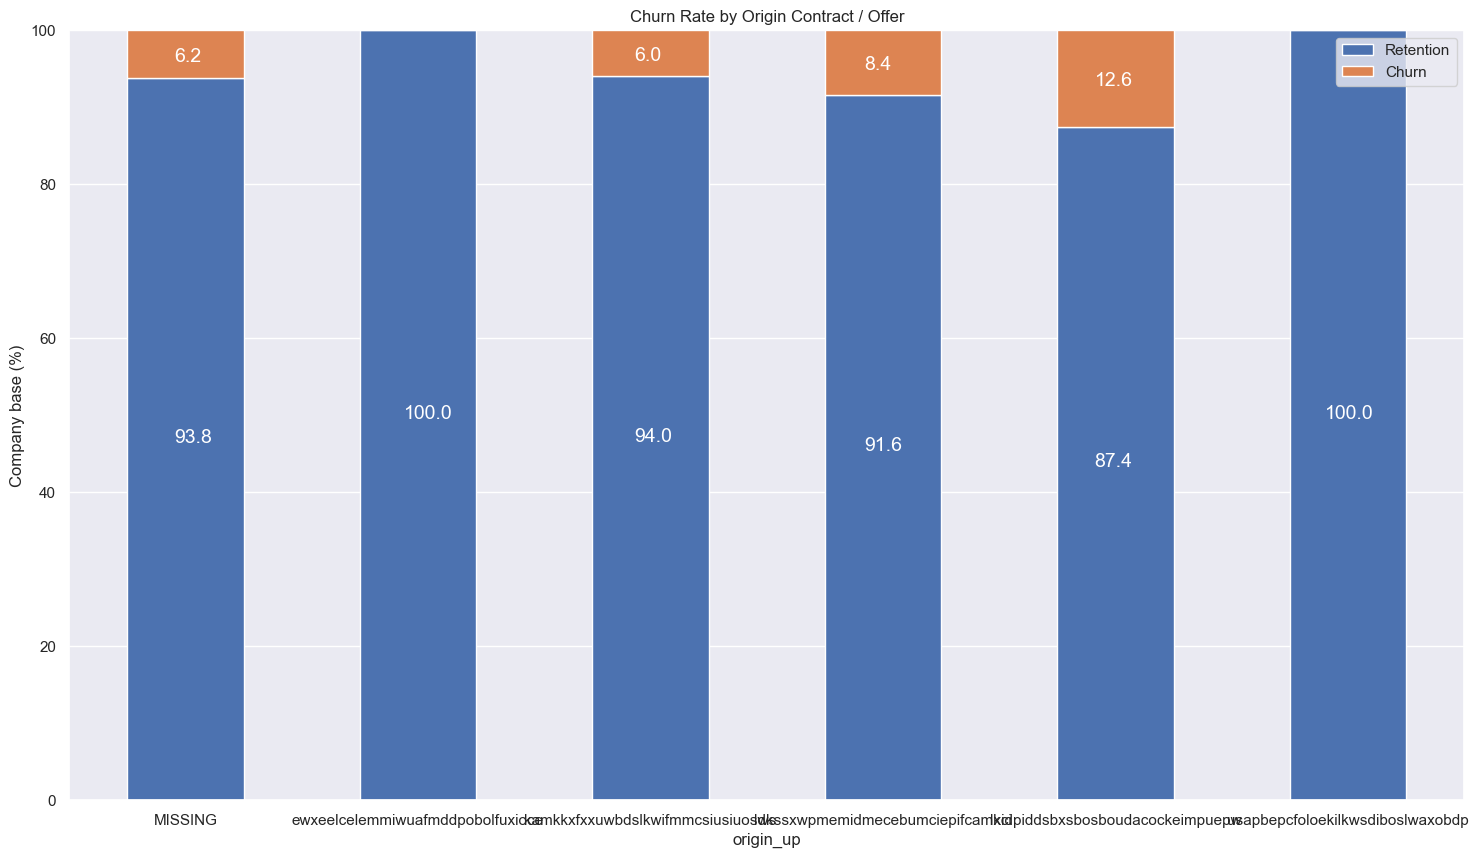

In [22]:
# --- Churn rate by Origin Contract / Offer ---
origin_churn = client_df.groupby(
    [client_df['origin_up'], client_df['churn']]
)['id'].count().unstack(level=1)

origin_percentage = (origin_churn.div(origin_churn.sum(axis=1), axis=0) * 100)
plot_stacked_bars(origin_percentage, 'Churn Rate by Origin Contract / Offer')

In [24]:
# Explore Categorical Columns
cat_cols = ['channel_sales', 'origin_up']

for col in cat_cols:
    print(f'\n--- {col} ---')
    print(client_df[col].value_counts(dropna=False))


--- channel_sales ---
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

--- origin_up ---
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


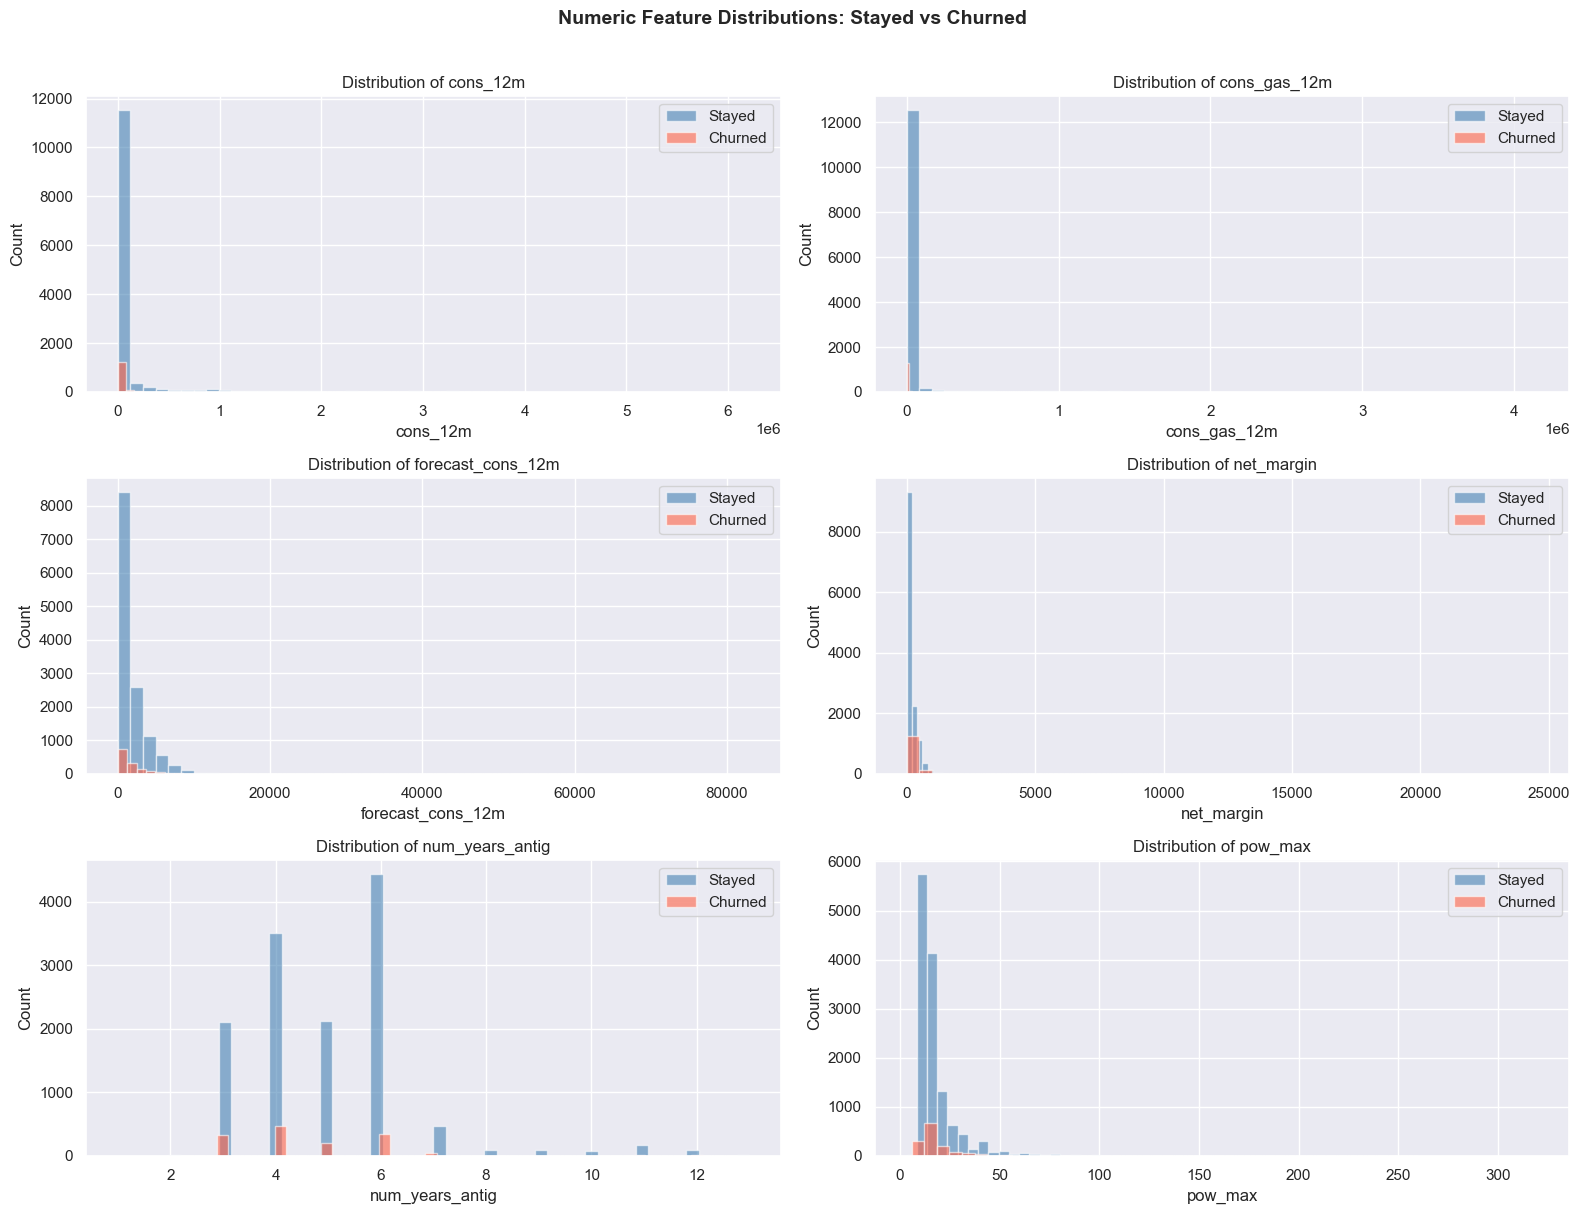

In [25]:
# Distribution plots for key numeric columns
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))

# List of columns to plot
cols_to_plot = [
    'cons_12m',      
    'cons_gas_12m', 
    'forecast_cons_12m', 
    'net_margin', 
    'num_years_antig', 
    'pow_max' 
]

for idx, col in enumerate(cols_to_plot):
    row = idx // 2
    col_pos = idx % 2
    ax = axs[row][col_pos]
    
    # Plot churned vs non-churned on same chart
    client_df[client_df['churn']==0][col].hist(
        bins=50, ax=ax, alpha=0.6, label='Stayed', color='steelblue')
    client_df[client_df['churn']==1][col].hist(
        bins=50, ax=ax, alpha=0.6, label='Churned', color='tomato')
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Numeric Feature Distributions: Stayed vs Churned', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# --- Date range of price data ---
print(f'Price data date range:')
print(f'  From: {price_df["price_date"].min().date()}')
print(f'  To:   {price_df["price_date"].max().date()}')
print(f'  Unique months: {price_df["price_date"].nunique()}')
print(f'  Unique customers: {price_df["id"].nunique():,}')

Price data date range:
  From: 2015-01-01
  To:   2015-12-01
  Unique months: 12
  Unique customers: 16,096


In [27]:
# --- Average price levels across all periods ---
price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
              'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

print('Average price per period:')
print(price_df[price_cols].mean().round(4))

Average price per period:
price_off_peak_var     0.1410
price_peak_var         0.0546
price_mid_peak_var     0.0305
price_off_peak_fix    43.3345
price_peak_fix        10.6229
price_mid_peak_fix     6.4100
dtype: float64


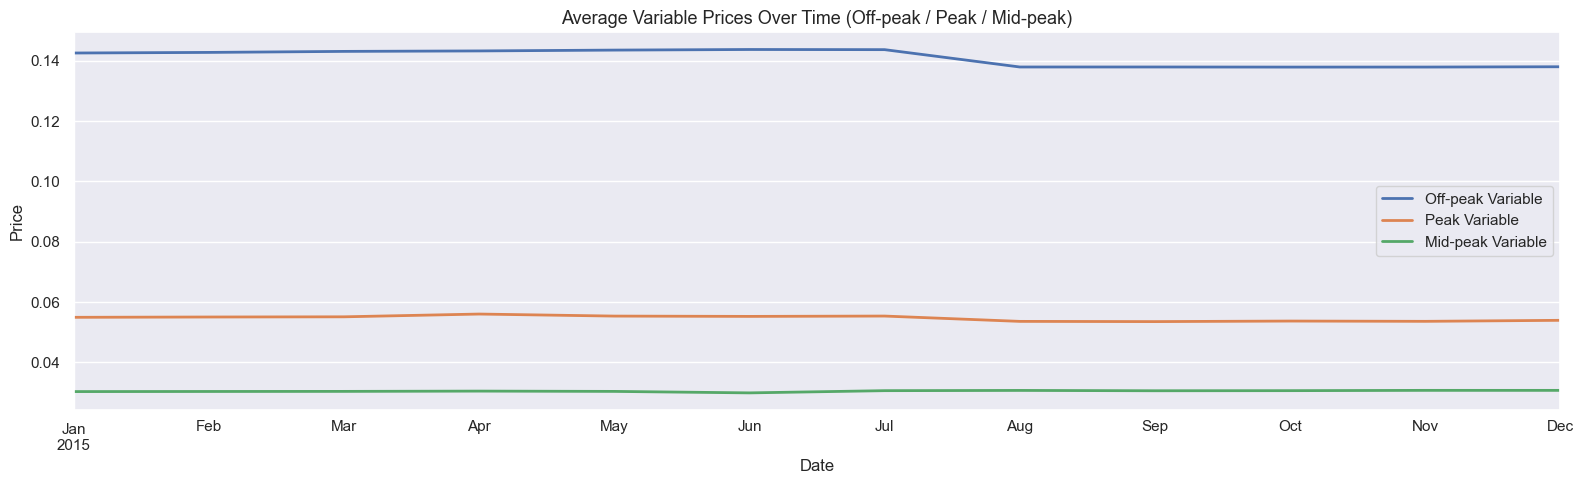

In [28]:
# --- Price trends over time (variable component) ---
avg_prices = price_df.groupby('price_date')[[
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var'
]].mean()

fig, ax = plt.subplots(figsize=(16, 5))
avg_prices.plot(ax=ax, linewidth=2)
ax.set_title('Average Variable Prices Over Time (Off-peak / Peak / Mid-peak)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(['Off-peak Variable', 'Peak Variable', 'Mid-peak Variable'])
plt.tight_layout()
plt.show()

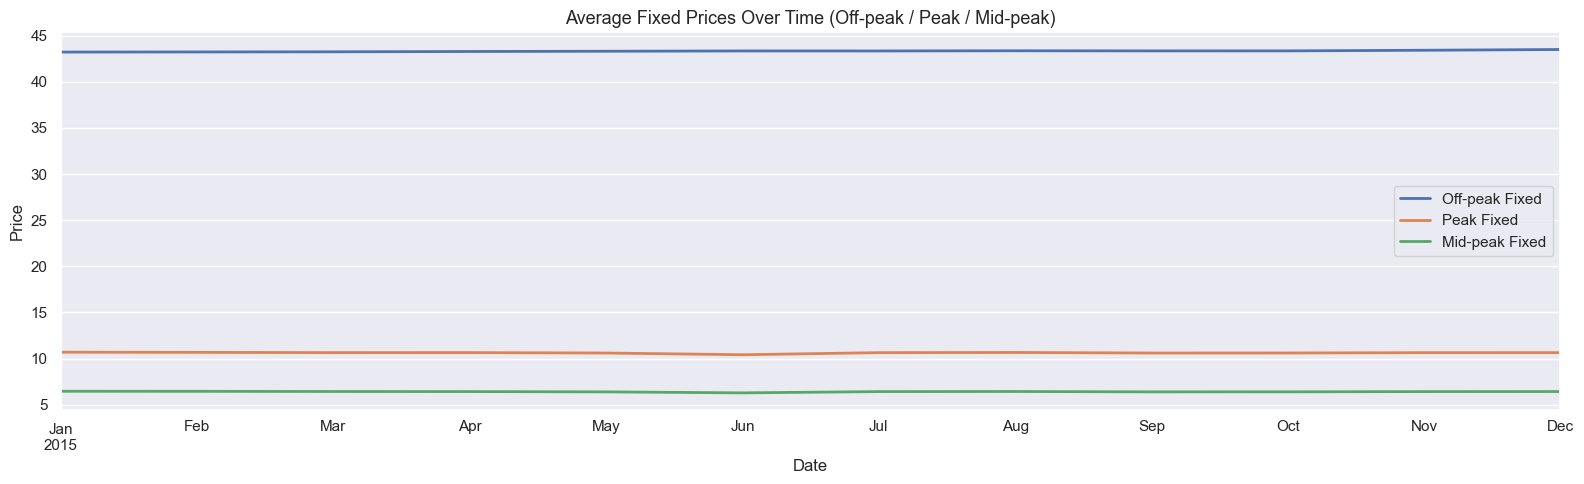

In [29]:
# --- Price trends over time (fixed component) ---
avg_prices_fix = price_df.groupby('price_date')[[
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'
]].mean()

fig, ax = plt.subplots(figsize=(16, 5))
avg_prices_fix.plot(ax=ax, linewidth=2)
ax.set_title('Average Fixed Prices Over Time (Off-peak / Peak / Mid-peak)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(['Off-peak Fixed', 'Peak Fixed', 'Mid-peak Fixed'])
plt.tight_layout()
plt.show()

In [30]:
# Quick EDA on price data
print("Price data shape:", price_df.shape)
print("\nDate range of price data:")
price_df['price_date'] = pd.to_datetime(price_df['price_date'])
print("From:", price_df['price_date'].min())
print("To:  ", price_df['price_date'].max())

# Average prices across periods
print("\nAverage prices:")
print(price_df[['price_off_peak_var','price_peak_var',
                'price_off_peak_fix','price_peak_fix']].mean())

Price data shape: (193002, 8)

Date range of price data:
From: 2015-01-01 00:00:00
To:   2015-12-01 00:00:00

Average prices:
price_off_peak_var     0.141027
price_peak_var         0.054630
price_off_peak_fix    43.334477
price_peak_fix        10.622875
dtype: float64
